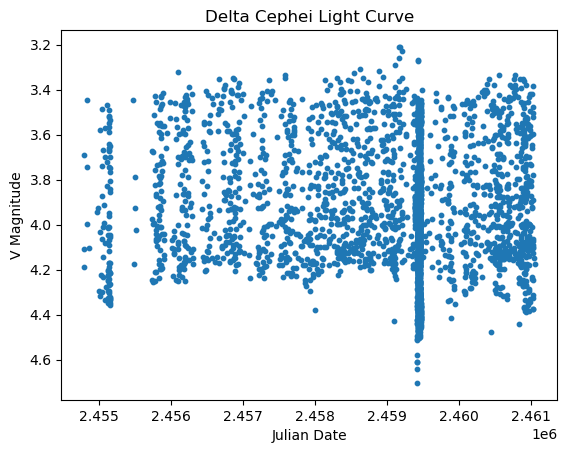

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

data = np.loadtxt("DelCep_Vmag.txt")

time = data[:, 0]     
mag = data[:, 1]   

plt.figure()
plt.scatter(time, mag, s=10)
plt.gca().invert_yaxis()   
plt.xlabel("Julian Date")
plt.ylabel("V Magnitude")
plt.title("Delta Cephei Light Curve")
plt.show()

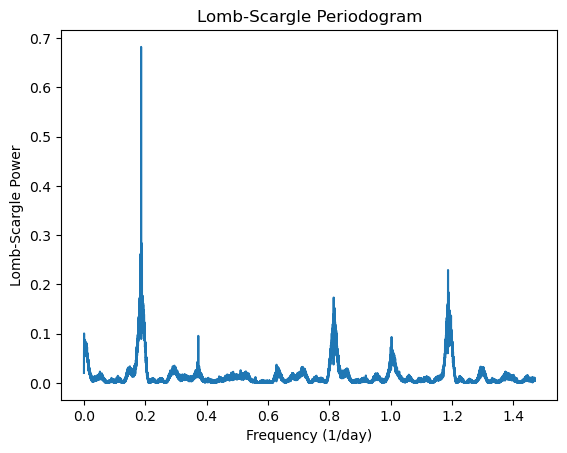

In [10]:
frequency, power = LombScargle(time, mag).autopower()

plt.figure()
plt.plot(frequency, power)
plt.xlabel("Frequency (1/day)")
plt.ylabel("Lomb-Scargle Power")
plt.title("Lomb-Scargle Periodogram")
plt.show()

In [11]:
frequency = frequency[np.argmax(power)]
period = 1 / frequency

print("period:", period)

period: 5.366197412390054


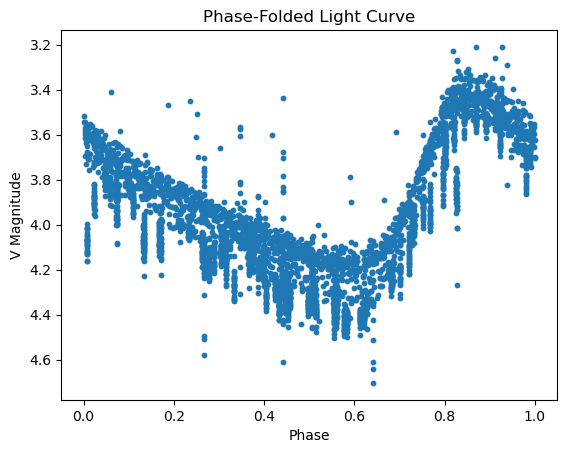

In [9]:
phase = (time % period) / period

plt.figure()
plt.scatter(phase, mag, s=10)
plt.gca().invert_yaxis()
plt.xlabel("Phase")
plt.ylabel("V Magnitude")
plt.title("Phase-Folded Light Curve")
plt.show()

Processing star: DelCep
No error column — using synthetic errors (10% of std).
Good V points: 3681


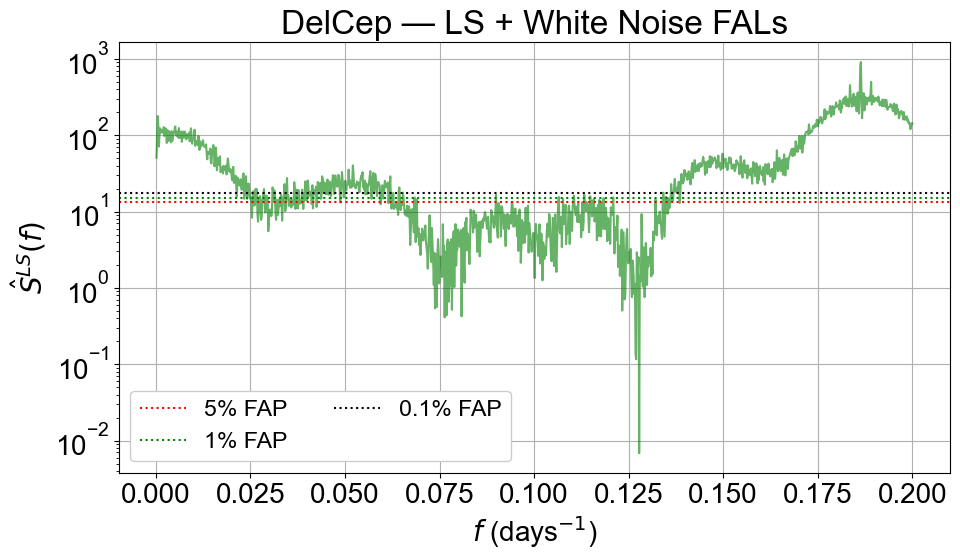

----------------------- POWER LAW FITTING RESULTS -------------------
Optimization terminated successfully.
Slope = 0.13
Intercept = 1.88
Whittle negative log-likelihood = 6245.28
----------------------- AR(1) FITTING RESULTS -------------------
Optimization terminated successfully.
Phi = 0.00
Sigma = 7.41
Whittle negative log-likelihood = 6268.07
----------------------- WHITE NOISE FITTING RESULTS -------------------
Optimization terminated successfully.
Power of white noise = 54.95
Whittle negative log-likelihood = 6268.07


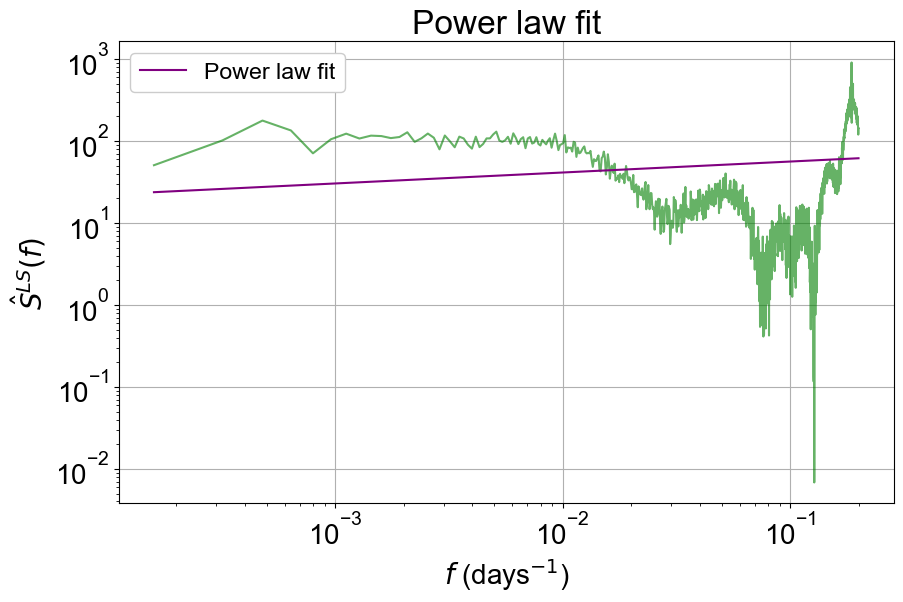

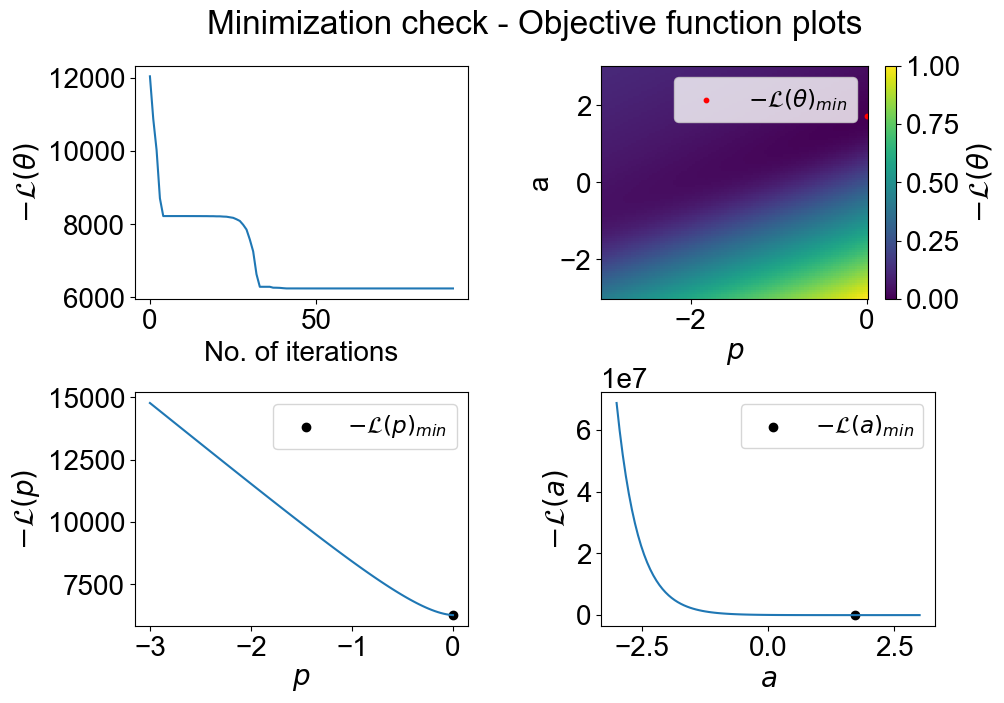

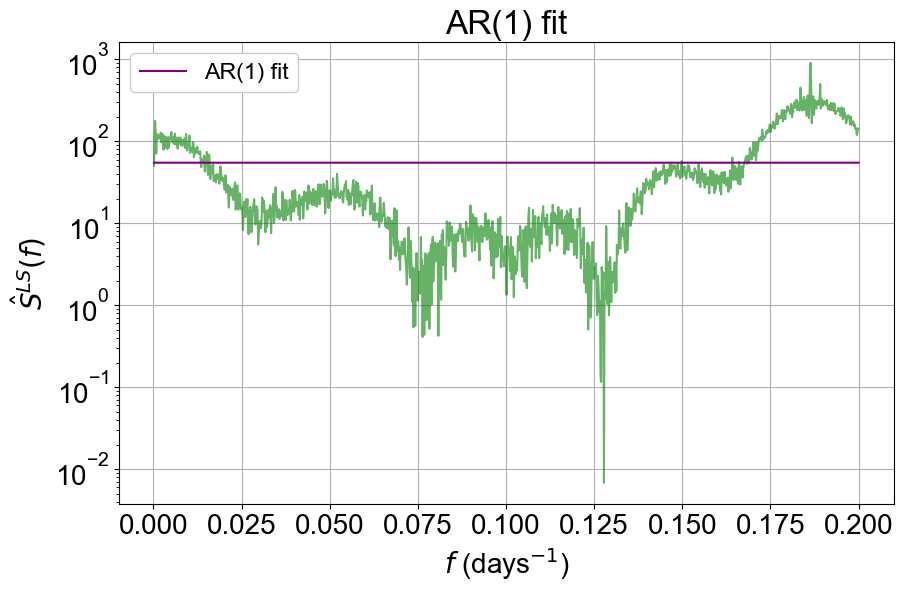

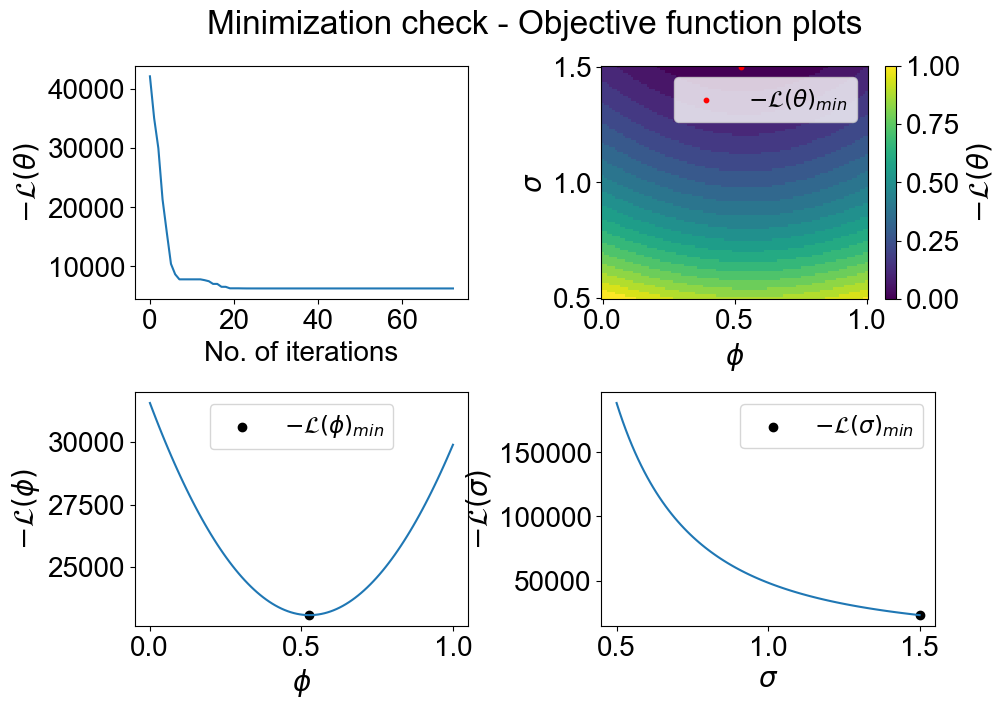

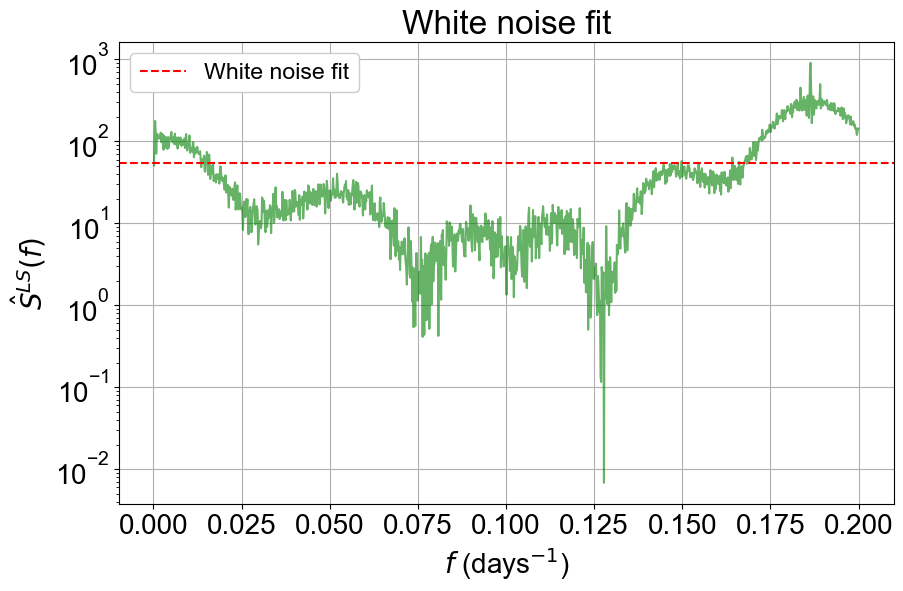

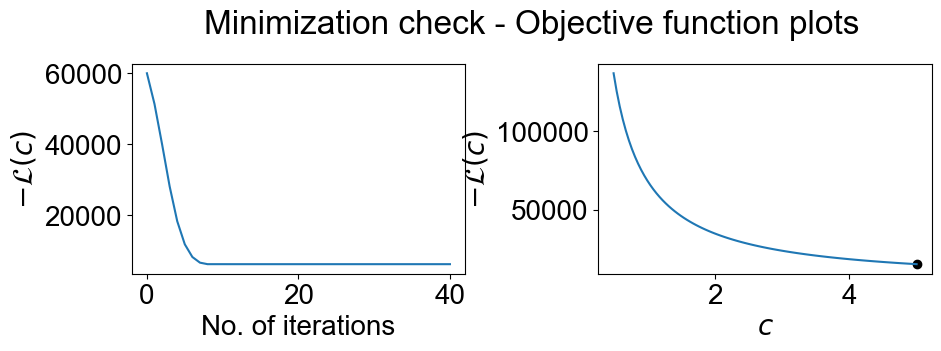


── Model comparison for DelCep (lower NLL = better) ──
  Power law   NLL: 6245.28  | slope=0.13, intercept=1.88
  AR(1)       NLL: 6268.07 | phi=0.00, sigma=7.41
  White noise NLL: 6268.07  | power=54.95
  → Best model: Power law

Loading existing bootstrap results from DelCep_fitting_results.txt
  Median NLL — PL: 6245.17, AR(1): 6267.87, WN: 6267.87


/var/folders/f1/ycblpyz16531mms2vrj6yt7c0000gn/T/ipykernel_55427/4010567823.py:143: RuntimeWarning: divide by zero encountered in log
  tau         = -1.0 / np.log(np.abs(phi_j))
/var/folders/f1/ycblpyz16531mms2vrj6yt7c0000gn/T/ipykernel_55427/4010567823.py:147: RuntimeWarning: divide by zero encountered in scalar divide
  new_obs[i] = new_obs[i-1] * np.exp(-(self.time[i] - self.time[i-1]) / tau) + epsilon[i]
/var/folders/f1/ycblpyz16531mms2vrj6yt7c0000gn/T/ipykernel_55427/4010567823.py:147: RuntimeWarning: invalid value encountered in scalar divide
  new_obs[i] = new_obs[i-1] * np.exp(-(self.time[i] - self.time[i-1]) / tau) + epsilon[i]


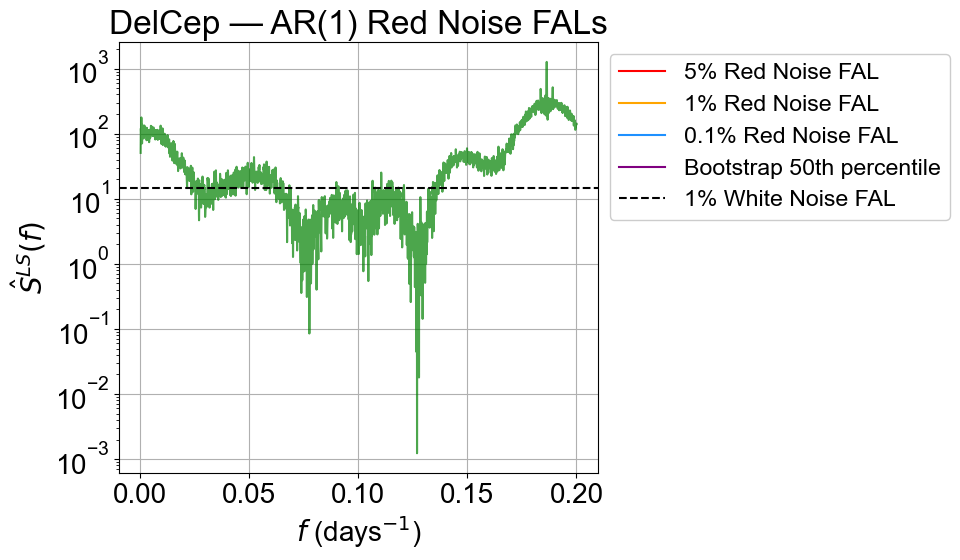

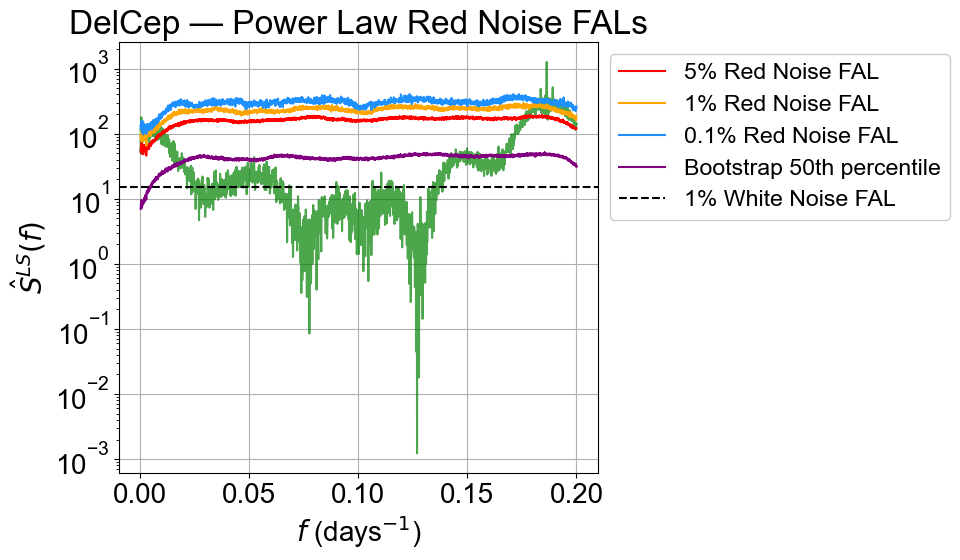


── DelCep — Period Detection Summary ──
  Best period : 5.366 days  (f = 0.18635 day⁻¹)
  Observed LS power : 1266.5921
  AR(1) FAL thresholds at best frequency:
    5%   FAL : nan
    1%   FAL : nan
    0.1% FAL : nan
  → Signal does NOT exceed 5% red noise FAL — not significant against red noise ✗


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import types
import os

from RedNoiseFALs import RedNoiseFALs

# ── 0. STAR NAME FROM FILENAME ────────────────────────────────────────────────

filename  = "DelCep.txt"
star_name = os.path.basename(filename).split(".")[0]  
print(f"Processing star: {star_name}")

# ── 1. LOAD & CLEAN DATA ──────────────────────────────────────────────────────

data      = np.genfromtxt(filename, skip_header=1, dtype=str)
mjd       = data[:, 0].astype(float)
V_mag_raw = data[:, 1]

if data.shape[1] > 2:
    V_err_raw = data[:, 2]
    mask  = (V_mag_raw != "--.---") & (V_err_raw != "-.---")
    mjd   = mjd[mask]
    V_mag = V_mag_raw[mask].astype(float)
    V_err = V_err_raw[mask].astype(float)
    print("Error column found — using real error bars.")
else:
    mask  = (V_mag_raw != "--.---")
    mjd   = mjd[mask]
    V_mag = V_mag_raw[mask].astype(float)
    V_err = np.full(len(V_mag), np.std(V_mag) * 0.1)
    print("No error column — using synthetic errors (10% of std).")

print(f"Good V points: {len(V_mag)}")

# ── 2. FREQUENCY LIMITS ───────────────────────────────────────────────────────

fmin = 1.0 / (mjd[-1] - mjd[0])
fmax = 0.2

# ── 3. RedNoiseFALs OBJECT ────────────────────────────────────────────────────

rn = RedNoiseFALs(
    time       = mjd,
    obs        = V_mag,
    eobs       = V_err,
    fmax       = fmax,
    fmin       = fmin,
    detrending = True,
    plot       = True
)
plt.title(f"{star_name} — LS + White Noise FALs")
plt.tight_layout()
plt.show()

# ── 4. FIT NOISE MODELS ───────────────────────────────────────────────────────

wl_pl,  slope,    intercept, _ = rn.pl_fit(
    x0=[-1.0, 0.0], plot_limits=[(-3, 0), (-3, 3)],
    Plot=True, Objective_plot=True
)
wl_ar1, phi,      sigma,     _ = rn.ar1_fit(
    x0=[0.5, 1.0],  plot_limits=[(0.001, 1), (0.5, 1.5)],
    Plot=True, Objective_plot=True
)
wl_wn,  power_wn,            _ = rn.wn_fit(
    x0=1.0,          plot_limits=[(0.5, 5)],
    Plot=True, Objective_plot=True
)
plt.show()

print(f"\n── Model comparison for {star_name} (lower NLL = better) ──")
print(f"  Power law   NLL: {wl_pl:.2f}  | slope={slope:.2f}, intercept={intercept:.2f}")
print(f"  AR(1)       NLL: {wl_ar1:.2f} | phi={phi:.2f}, sigma={sigma:.2f}")
print(f"  White noise NLL: {wl_wn:.2f}  | power={power_wn:.2f}")

best_model = min([("Power law", wl_pl), ("AR(1)", wl_ar1), ("White noise", wl_wn)],
                  key=lambda x: x[1])
print(f"  → Best model: {best_model[0]}")

# ── 5. BOOTSTRAP DISTRIBUTIONS ───────────────────────────────────────────────

save_file = f"{star_name}_fitting_results.txt"

# Load existing results if available, otherwise run gen_distributions
if os.path.exists(save_file):
    print(f"\nLoading existing bootstrap results from {save_file}")
    results        = np.loadtxt(save_file, skiprows=1)
    dist_slope     = results[:, 1]
    dist_intercept = results[:, 2]
    dist_phi       = results[:, 4]
    dist_sigma     = results[:, 5]
    dist_pl_wl     = results[:, 0]
    dist_ar1_wl    = results[:, 3]
    dist_wn_wl     = results[:, 6]
else:
    print(f"\nRunning bootstrap (n=1000) — this may take a while...")
    dist_pl_wl, dist_ar1_wl, dist_wn_wl, \
    dist_slope, dist_intercept, \
    dist_phi, dist_sigma = rn.gen_distributions(
        n_bootstrap = 1000,
        histograms  = True,
        save_file   = save_file
    )
    plt.title(f"{star_name} — Whittle NLL Distributions")
    plt.tight_layout()
    plt.show()

print(f"  Median NLL — PL: {np.median(dist_pl_wl):.2f}, "
      f"AR(1): {np.median(dist_ar1_wl):.2f}, "
      f"WN: {np.median(dist_wn_wl):.2f}")

# ── 6. PATCHED FAL METHODS (fixes shape mismatch bug) ────────────────────────

def fal_ar1_fixed(self, phi, sigma, n_bootstrap=10000, Plot=True, title="FALs based on AR(1)"):
    if isinstance(phi, np.ndarray) and isinstance(sigma, np.ndarray):
        if not (len(phi) == len(sigma) == n_bootstrap):
            print("Length of phi and sigma distributions must equal n_bootstrap")
            return

    t    = self.time[-1] - self.time[0]
    rr   = 0.5 / t
    fgrid = np.linspace(rr, self.fnyq, num=int((self.fnyq / rr) * 3), endpoint=True)

    if self.fmin != "Default":
        idx   = np.argmin(np.abs(fgrid - self.fmin))
        fgrid = fgrid[idx:]

    N_gridpoints = len(fgrid)  # ✅ fix: derive after trimming
    n            = len(self.time)
    spec         = np.zeros((N_gridpoints, n_bootstrap))
    rand_int     = np.random.randn(n_bootstrap)
    new_obs      = np.zeros(n)

    ls_real   = LombScargle(self.time, self.obs, normalization="psd")
    LS_real   = ls_real.power(fgrid)
    fal_white = ls_real.false_alarm_level([0.05, 0.01, 0.001], method='bootstrap')

    for j in range(n_bootstrap):
        phi_j   = phi[j]   if isinstance(phi,   np.ndarray) else phi
        sigma_j = sigma[j] if isinstance(sigma, np.ndarray) else sigma
        tau         = -1.0 / np.log(np.abs(phi_j))
        new_obs[0]  = rand_int[j]
        epsilon     = sigma_j * np.random.randn(n)
        for i in range(1, n):
            new_obs[i] = new_obs[i-1] * np.exp(-(self.time[i] - self.time[i-1]) / tau) + epsilon[i]
        Obs        = new_obs / np.std(new_obs)
        spec[:, j] = LombScargle(self.time, Obs, normalization="psd").power(fgrid)

    percentiles = np.percentile(spec, [95.0, 99.0, 99.9, 50.0], axis=1).T

    if Plot:
        plt.figure(figsize=(10, 6))
        plt.title(title)
        plt.xlabel(r"$f$ (days$^{-1}$)")
        plt.ylabel(r"$\hat{S}^{LS}(f)$")
        plt.semilogy(fgrid, LS_real,            color="green",      alpha=0.7)
        plt.semilogy(fgrid, percentiles[:, 0],  color="red",        label="5% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 1],  color="orange",     label="1% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 2],  color="dodgerblue", label="0.1% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 3],  color="purple",     label=r"Bootstrap 50th percentile")
        plt.axhline(fal_white[1], linestyle='--', color='black',    label="1% White Noise FAL")
        plt.grid(axis="both")
        plt.legend(fontsize='small', facecolor='white', framealpha=1, bbox_to_anchor=(1.0, 1.0))
    return percentiles, fgrid


def fal_pl_fixed(self, slope, intercept, n_bootstrap=10000, Plot=True, title="FALs based on power law"):
    if isinstance(slope, np.ndarray) and isinstance(intercept, np.ndarray):
        if not (len(slope) == len(intercept) == n_bootstrap):
            print("Length of slope and intercept distributions must equal n_bootstrap")
            return

    t     = self.time[-1] - self.time[0]
    rr    = 0.5 / t
    fgrid = np.linspace(rr, self.fnyq, num=int((self.fnyq / rr) * 3), endpoint=True)

    if self.fmin != "Default":
        idx   = np.argmin(np.abs(fgrid - self.fmin))
        fgrid = fgrid[idx:]

    N_gridpoints = len(fgrid)  # ✅ fix: derive after trimming
    n            = len(self.time)
    flog         = np.log10(fgrid)
    delta_w      = 2 * np.pi * (fgrid[1] - fgrid[0])
    time_shifted = self.time - self.time[0]
    spec         = np.zeros((N_gridpoints, n_bootstrap))
    rand_int     = np.random.randn(n_bootstrap)

    ls_real   = LombScargle(self.time, self.obs, normalization="psd")
    LS_real   = ls_real.power(fgrid)
    fal_white = ls_real.false_alarm_level([0.05, 0.01, 0.001], method='bootstrap')

    for j in range(n_bootstrap):
        slope_j     = slope[j]     if isinstance(slope,     np.ndarray) else slope
        intercept_j = intercept[j] if isinstance(intercept, np.ndarray) else intercept
        ps_pl       = 10 ** (slope_j * flog + intercept_j)
        phi_k       = np.random.rand(N_gridpoints) * 2 * np.pi
        new_obs     = np.zeros(n)
        for i in range(n):
            new_obs[i] = np.sum(np.sqrt(ps_pl * delta_w) * np.cos(2 * np.pi * fgrid * time_shifted[i] + phi_k))
        new_obs    = new_obs / np.std(new_obs)
        spec[:, j] = LombScargle(time_shifted, new_obs, normalization="psd").power(fgrid)

    percentiles = np.percentile(spec, [95.0, 99.0, 99.9, 50.0], axis=1).T

    if Plot:
        plt.figure(figsize=(10, 6))
        plt.title(title)
        plt.xlabel(r"$f$ (days$^{-1}$)")
        plt.ylabel(r"$\hat{S}^{LS}(f)$")
        plt.semilogy(fgrid, LS_real,            color="green",      alpha=0.7)
        plt.semilogy(fgrid, percentiles[:, 0],  color="red",        label="5% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 1],  color="orange",     label="1% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 2],  color="dodgerblue", label="0.1% Red Noise FAL")
        plt.semilogy(fgrid, percentiles[:, 3],  color="purple",     label=r"Bootstrap 50th percentile")
        plt.axhline(fal_white[1], linestyle='--', color='black',    label="1% White Noise FAL")
        plt.grid(axis="both")
        plt.legend(fontsize='small', facecolor='white', framealpha=1, bbox_to_anchor=(1.0, 1.0))
    return percentiles, fgrid


# Bind patched methods
rn.fal_ar1 = types.MethodType(fal_ar1_fixed, rn)
rn.fal_pl  = types.MethodType(fal_pl_fixed,  rn)

# ── 7. COMPUTE RED NOISE FALs ─────────────────────────────────────────────────

percentiles_ar1, fgrid_ar1 = rn.fal_ar1(
    phi=dist_phi, sigma=dist_sigma, n_bootstrap=1000,
    title=f"{star_name} — AR(1) Red Noise FALs"
)
plt.tight_layout()
plt.show()

percentiles_pl, fgrid_pl = rn.fal_pl(
    slope=dist_slope, intercept=dist_intercept, n_bootstrap=1000,
    title=f"{star_name} — Power Law Red Noise FALs"
)
plt.tight_layout()
plt.show()

# ── 8. FIND BEST PERIOD & CHECK AGAINST FALs ─────────────────────────────────

# Use the fgrid returned directly from fal_ar1 — no recomputation needed
V_norm   = (V_mag - np.mean(V_mag)) / np.std(V_mag)
LS_power = LombScargle(mjd, V_norm, normalization="psd").power(fgrid_ar1)

best_idx    = np.argmax(LS_power)
best_freq   = fgrid_ar1[best_idx]
best_period = 1.0 / best_freq
best_power  = LS_power[best_idx]

# Trim arrays to same length for safe indexing
min_len         = min(len(fgrid_ar1), len(percentiles_ar1))
fgrid_ar1       = fgrid_ar1[:min_len]
LS_power        = LS_power[:min_len]
percentiles_ar1 = percentiles_ar1[:min_len]

idx_best = np.argmin(np.abs(fgrid_ar1 - best_freq))

print(f"\n── {star_name} — Period Detection Summary ──")
print(f"  Best period : {best_period:.3f} days  (f = {best_freq:.5f} day⁻¹)")
print(f"  Observed LS power : {best_power:.4f}")
print(f"  AR(1) FAL thresholds at best frequency:")
print(f"    5%   FAL : {percentiles_ar1[idx_best, 0]:.4f}")
print(f"    1%   FAL : {percentiles_ar1[idx_best, 1]:.4f}")
print(f"    0.1% FAL : {percentiles_ar1[idx_best, 2]:.4f}")

if best_power > percentiles_ar1[idx_best, 2]:
    print("  → Signal exceeds 0.1% red noise FAL (99.9% significant) ✓")
elif best_power > percentiles_ar1[idx_best, 1]:
    print("  → Signal exceeds 1% red noise FAL (99% significant) ✓")
elif best_power > percentiles_ar1[idx_best, 0]:
    print("  → Signal exceeds 5% red noise FAL (95% significant) ✓")
else:
    print("  → Signal does NOT exceed 5% red noise FAL — not significant against red noise ✗")